# Итоговый проект Skillbox: модель кредитного риск-менеджмента

**Задача:** бинарная классификация целевой переменной `flag`.

**Особенность данных:** одной заявке `id` соответствует несколько записей кредитной истории.  
Поэтому главный этап проекта — агрегировать кредитную историю до уровня одной заявки.

В этом ноутбуке оставлен рабочий пайплайн:

1. загрузка данных
2. построение признаков
3. обучение нескольких моделей:
   - Logistic Regression
   - Decision Tree
   - Random Forest
   - CatBoost
4. сравнение результатов
5. анализ важности признаков Random Forest
6. проверка Top-N признаков.

## Что добавлено для устойчивости

Ноутбук работает через checkpoint-файлы для сохранения предыдущих резулоьтатов и сохранения памяти:

- признаки `features_v1.parquet` ... `features_v8.parquet`
- промежуточные part-файлы по каждому исходному `train_data_*.pq`
- результаты каждой модели в `json`
- общая таблица `experiments_summary.csv`
- результаты проверки Top-N признаков.

Если ноутбук упадёт или закончится память, повторный запуск **не начинает всё сначала**:
готовые файлы загружаются с диска, а недостающие шаги достраиваются.

**Важно по памяти:** версии признаков `v1`–`v8` не хранятся одновременно в RAM.  
Каждая версия строится, сохраняется в `parquet`, после чего удаляется из памяти.  
Во время обучения признаки также загружаются по одной версии.


## 1. Импорты, пути и настройки

In [1]:
from pathlib import Path
from datetime import datetime
import gc
import json
import warnings

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier, Pool
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")

# Базовая папка проекта.
DATA_PATH = Path(".")
DATA_PATH_TRAIN_DATA = DATA_PATH / "train_data"
TARGET_PATH = DATA_PATH / "train_target.csv"

# Папка для всех промежуточных файлов.
# Если ноутбук упадёт или закончится память, повторный запуск начнётся
# с уже сохранённых, а не с самого начала.
CHECKPOINT_DIR = DATA_PATH / "checkpoints"
FEATURES_DIR = CHECKPOINT_DIR / "features"
FEATURE_PARTS_DIR = CHECKPOINT_DIR / "feature_parts"
RESULTS_DIR = CHECKPOINT_DIR / "results"
IMPORTANCES_DIR = CHECKPOINT_DIR / "importances"
TOPN_DIR = CHECKPOINT_DIR / "topn"

for directory in [
    CHECKPOINT_DIR,
    FEATURES_DIR,
    FEATURE_PARTS_DIR,
    RESULTS_DIR,
    IMPORTANCES_DIR,
    TOPN_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

# Если нужно принудительно пересобрать признаки или переобучить модели,
# поменять нужный флаг на True.
FORCE_REBUILD_FEATURES = False
FORCE_RETRAIN_MODELS = False
FORCE_RETRAIN_TOPN = False

FEATURE_VERSIONS = ["v1", "v2", "v3", "v4", "v5", "v6", "v7", "v8"]

# Пути к итоговым таблицам признаков.
FEATURE_PATHS = {
    version: FEATURES_DIR / f"features_{version}.parquet"
    for version in FEATURE_VERSIONS
}

EXPERIMENTS_SUMMARY_PATH = RESULTS_DIR / "experiments_summary.csv"

## 2. Проверка входных файлов и загрузка target

Логика:

- если итоговые признаки уже сохранены в `checkpoints/features`, исходные `train_data_*.pq` не нужны для пересчёта признаков;
- если каких-то признаков ещё нет, исходные parquet-файлы нужны;
- `target` нужен только для обучения моделей. Если все результаты моделей уже сохранены и переобучение выключено, notebook может показать уже готовую таблицу результатов без нового обучения.


In [2]:
# Проверяем, какие версии признаков уже готовы.
existing_feature_versions = [
    version
    for version, path in FEATURE_PATHS.items()
    if path.exists()
]

missing_feature_versions = [
    version
    for version in FEATURE_VERSIONS
    if version not in existing_feature_versions
]

print("Готовые версии признаков:", existing_feature_versions)
print("Отсутствующие версии признаков:", missing_feature_versions)

# Исходные parquet-файлы нужны только если нужно строить недостающие признаки
# или включён принудительный пересчёт.
need_raw_train_data = bool(missing_feature_versions) or FORCE_REBUILD_FEATURES

if need_raw_train_data:
    files = sorted(DATA_PATH_TRAIN_DATA.glob("train_data_*.pq"))

    print("\nСтроим признаки, проверяем исходные train_data_*.pq")

    if len(files) > 0:
        print("Первый файл:", files[0])
        print("Последний файл:", files[-1])
    else:
        raise FileNotFoundError(
            "Не найдены parquet-файлы в папке train_data. "
            "Они нужны, потому что часть признаков ещё не сохранена."
        )
else:
    # Сырые данные не читаем и не требуем.
    files = []
    print("\nВсе признаки уже есть. Исходные train_data_*.pq сейчас не нужны.")

# Target нужен для обучения моделей.
# Если target отсутствует, но все результаты уже сохранены, можно будет
# посмотреть готовую experiments_summary.csv без переобучения.
if TARGET_PATH.exists():
    target = pd.read_csv(TARGET_PATH)

    print("\nTarget shape:", target.shape)
    print("Unique id:", target["id"].nunique())
    print("Duplicate id:", target["id"].duplicated().sum())

    display(target.head())
else:
    target = None
    print("\nФайл train_target.csv не найден.")
    print("Обучение моделей невозможно, но готовые результаты из checkpoints/results можно посмотреть.")

Готовые версии признаков: ['v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8']
Отсутствующие версии признаков: []

Все признаки уже есть. Исходные train_data_*.pq сейчас не нужны.

Target shape: (3000000, 2)
Unique id: 3000000
Duplicate id: 0


,id,flag
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


## 3. Вспомогательные функции

In [3]:
def clear_memory():
    # Принудительно очищает память между тяжёлыми шагами.
    gc.collect()
    print("Memory cleared")


def save_json(data, path):
    # Сохраняет словарь в json.
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as file:
        json.dump(data, file, ensure_ascii=False, indent=2)


def load_json(path):
    # Загружает словарь из json.
    with open(path, "r", encoding="utf-8") as file:
        return json.load(file)


def read_experiments_summary():
    # Загружает общую таблицу экспериментов, если она уже существует.
    if EXPERIMENTS_SUMMARY_PATH.exists():
        return (
            pd.read_csv(EXPERIMENTS_SUMMARY_PATH)
            .sort_values("test_roc_auc", ascending=False)
            .reset_index(drop=True)
        )

    return pd.DataFrame(
        columns=[
            "features_version",
            "model",
            "train_roc_auc",
            "test_roc_auc",
            "gap",
            "n_features",
            "created_at",
        ]
    )


def upsert_experiment_summary(row):
    # Добавляет или обновляет строку в experiments_summary.csv.
    #
    # Это главный checkpoint таблицы результатов.
    # После каждого обученного эксперимента результат сразу записывается на диск.
    # Поэтому при падении ноутбука уже полученные метрики не теряются.
    row = dict(row)
    row["created_at"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    summary = read_experiments_summary()

    if len(summary) > 0:
        mask = (
            (summary["features_version"] == row["features_version"])
            & (summary["model"] == row["model"])
        )
        summary = summary.loc[~mask].copy()

    summary = pd.concat([summary, pd.DataFrame([row])], ignore_index=True)
    summary = (
        summary
        .sort_values("test_roc_auc", ascending=False)
        .reset_index(drop=True)
    )

    EXPERIMENTS_SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)
    summary.to_csv(EXPERIMENTS_SUMMARY_PATH, index=False)

    return summary


def result_path(version, model_name):
        # Путь к json-файлу с метриками модели.
    safe_model = model_name.lower().replace(" ", "_")
    return RESULTS_DIR / f"{version}__{safe_model}.json"


def importance_path(version):
        # Путь к parquet-файлу с важностями Random Forest.
    return IMPORTANCES_DIR / f"{version}__random_forest_importance.parquet"


def save_model_result(version, model_name, result):
    # Сохраняет метрики модели в json и обновляет experiments_summary.csv.
    #
    # Модель, X_train и X_test не сохраняем, чтобы не занимать память и диск.
    # Сохраняем только то, что нужно для анализа и защиты:
    # - train ROC-AUC;
    # - test ROC-AUC;
    # - gap;
    # - список признаков;
    # - количество признаков.
    payload = {
        "features_version": version,
        "model": model_name,
        "train_auc": float(result["train_auc"]),
        "test_auc": float(result["test_auc"]),
        "gap": float(result["train_auc"] - result["test_auc"]),
        "n_features": int(len(result["feature_names"])),
        "feature_names": list(result["feature_names"]),
        "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    }

    save_json(payload, result_path(version, model_name))

    upsert_experiment_summary({
        "features_version": version,
        "model": model_name,
        "train_roc_auc": payload["train_auc"],
        "test_roc_auc": payload["test_auc"],
        "gap": payload["gap"],
        "n_features": payload["n_features"],
    })

    return payload


def experiment_row_from_json(version, model_name):
    # Возвращает строку результата из json-checkpoint.
    item = load_json(result_path(version, model_name))

    return {
        "features_version": item["features_version"],
        "model": item["model"],
        "train_roc_auc": item["train_auc"],
        "test_roc_auc": item["test_auc"],
        "gap": item["gap"],
        "n_features": item["n_features"],
    }


def load_all_experiment_results():
    # Загружает все сохранённые метрики моделей из checkpoints/results.
    #
    # Если есть experiments_summary.csv, используем его.
    # Если его нет, восстанавливаем таблицу из отдельных json-файлов.
    if EXPERIMENTS_SUMMARY_PATH.exists():
        return read_experiments_summary()

    rows = []

    for path in sorted(RESULTS_DIR.glob("*.json")):
        item = load_json(path)
        rows.append({
            "features_version": item["features_version"],
            "model": item["model"],
            "train_roc_auc": item["train_auc"],
            "test_roc_auc": item["test_auc"],
            "gap": item["gap"],
            "n_features": item["n_features"],
            "created_at": item.get("created_at"),
        })

    if len(rows) == 0:
        return read_experiments_summary()

    summary = (
        pd.DataFrame(rows)
        .sort_values("test_roc_auc", ascending=False)
        .reset_index(drop=True)
    )

    summary.to_csv(EXPERIMENTS_SUMMARY_PATH, index=False)
    return summary


def validate_features(features, name="features"):
    # Базовые проверки таблицы признаков.
    print(f"{name} shape:", features.shape)
    print(f"{name} unique id:", features["id"].nunique())
    print(f"{name} duplicated id:", features["id"].duplicated().sum())

    missing = features.isna().mean().sort_values(ascending=False)

    print("\nTop missing values:")
    display(missing.head(15).to_frame("missing_share"))

    return missing


def build_features_all_files(
    build_func,
    output_path,
    version_name,
    force_rebuild=FORCE_REBUILD_FEATURES,
):
    # Строит признаки по всем parquet-файлам с checkpoint по каждому файлу.
    #
    # Повторный запуск:
    # - если итоговый файл уже существует, он просто загружается;
    # - если часть part-файлов уже существует, они не пересчитываются;
    # - в памяти одновременно находится только один исходный parquet-файл.
    output_path = Path(output_path)
    part_dir = FEATURE_PARTS_DIR / version_name
    part_dir.mkdir(parents=True, exist_ok=True)

    if output_path.exists() and not force_rebuild:
        print("Итоговый файл уже существует, загружаем:", output_path)
        features = pd.read_parquet(output_path)
        print("Features shape:", features.shape)
        print("Unique id:", features["id"].nunique())
        return features

    if len(files) == 0:
        raise RuntimeError(
            f"Нельзя построить {version_name}: список исходных train_data_*.pq пуст. "
            "Проверь DATA_PATH_TRAIN_DATA или наличие готового features parquet."
        )

    part_paths = []

    for file in files:
        part_path = part_dir / f"{file.stem}__{version_name}.parquet"
        part_paths.append(part_path)

        if part_path.exists() and not force_rebuild:
            print("Part уже существует, пропускаем:", part_path.name)
            continue

        print(f"Processing {version_name}: {file.name}")
        df = pd.read_parquet(file)

        part = build_func(df)
        part.to_parquet(part_path, index=False)

        print("Saved part:", part_path)

        del df, part
        clear_memory()

    print(f"\nСобираем итоговые признаки {version_name} из part-файлов")

    features_parts = []
    for part_path in part_paths:
        features_parts.append(pd.read_parquet(part_path))

    features = pd.concat(features_parts, ignore_index=True)

    # На всякий случай объединяем повторяющиеся id.
    # Если id встречается в нескольких train_data-файлах, берём max по агрегатам.
    if features["id"].duplicated().sum() > 0:
        print("Есть повторяющиеся id между part-файлами. Объединяем через max.")
        features = features.groupby("id", as_index=False).max()

    features.to_parquet(output_path, index=False)

    print("Saved final features:", output_path)
    print("Features shape:", features.shape)
    print("Unique id:", features["id"].nunique())

    del features_parts
    # clear_memory()

    return features


def prepare_model_data(features, random_state=RANDOM_STATE):
    # Объединяет признаки с target и делает train/test split.
    #
    # - NaN заполняем нулями после агрегации;
    # - признаки приводим к float32, чтобы снизить потребление памяти.
    if target is None:
        raise RuntimeError(
            "train_target.csv не загружен. "
            "Для обучения моделей нужен target."
        )
    target_like_cols = [
        col for col in features.columns
        if col == "flag" or col.startswith("flag_")
    ]

    if target_like_cols:
        print("Removed target-like columns from features:", target_like_cols)
        features = features.drop(columns=target_like_cols)
    df_model = features.merge(
        target[["id", "flag"]],
        on="id",
        how="inner",
    ).fillna(0)

    X = df_model.drop(columns=["id", "flag"]).astype("float32")
    y = df_model["flag"].astype("int8")

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=random_state,
        stratify=y,
    )

    del df_model, X, y
    gc.collect()

    return X_train, X_test, y_train, y_test


def add_experiment_result(experiments, version, model_name, result):
    # Добавляет результат эксперимента в локальный список и возвращает таблицу.
    experiments.append({
        "features_version": version,
        "model": model_name,
        "train_roc_auc": result["train_auc"],
        "test_roc_auc": result["test_auc"],
        "gap": result["train_auc"] - result["test_auc"],
        "n_features": len(result["feature_names"]),
    })

    return pd.DataFrame(experiments).sort_values("test_roc_auc", ascending=False)


## 4. Функции обучения моделей

In [4]:
def test_features_lr(features, random_state=RANDOM_STATE):
    # Logistic Regression — линейный baseline.
    #
    # Масштабирование обязательно, потому что Logistic Regression чувствительна
    # к масштабу признаков.
    #
    # Для экономии памяти функция возвращает только метрики и список признаков,
    # а не X_train/X_test.
    X_train, X_test, y_train, y_test = prepare_model_data(features, random_state)
    feature_names = list(X_train.columns)

    lr_pipeline = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ))
    ])

    lr_pipeline.fit(X_train, y_train)

    train_pred = lr_pipeline.predict_proba(X_train)[:, 1]
    test_pred = lr_pipeline.predict_proba(X_test)[:, 1]

    train_auc = roc_auc_score(y_train, train_pred)
    test_auc = roc_auc_score(y_test, test_pred)

    print(f"Train LR ROC-AUC: {train_auc:.6f}")
    print(f"Test  LR ROC-AUC: {test_auc:.6f}")

    del X_train, X_test, y_train, y_test
    del train_pred, test_pred, lr_pipeline
    gc.collect()

    return {
        "feature_names": feature_names,
        "train_auc": train_auc,
        "test_auc": test_auc,
    }


def test_features_dt(
    features,
    max_depth=6,
    min_samples_leaf=100,
    random_state=RANDOM_STATE,
):
    # Decision Tree — простая нелинейная модель.
    X_train, X_test, y_train, y_test = prepare_model_data(features, random_state)
    feature_names = list(X_train.columns)

    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        class_weight="balanced",
        random_state=random_state,
    )

    model.fit(X_train, y_train)

    train_pred = model.predict_proba(X_train)[:, 1]
    test_pred = model.predict_proba(X_test)[:, 1]

    train_auc = roc_auc_score(y_train, train_pred)
    test_auc = roc_auc_score(y_test, test_pred)

    print(f"Train DT ROC-AUC: {train_auc:.6f}")
    print(f"Test  DT ROC-AUC: {test_auc:.6f}")

    del X_train, X_test, y_train, y_test
    del train_pred, test_pred, model
    gc.collect()

    return {
        "feature_names": feature_names,
        "train_auc": train_auc,
        "test_auc": test_auc,
    }


def test_features_rf(
    features,
    n_estimators=500,
    max_depth=18,
    min_samples_leaf=20,
    random_state=RANDOM_STATE,
):
    # Random Forest — одна из важных моделей.
    X_train, X_test, y_train, y_test = prepare_model_data(features, random_state)
    feature_names = list(X_train.columns)

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        class_weight="balanced",
        max_features="sqrt",
        random_state=random_state,
        n_jobs=-1,
    )

    X_train = X_train.reset_index(drop=True)
    X_test = X_test.reset_index(drop=True)

    y_train = np.asarray(y_train, dtype=np.int8)
    y_test = np.asarray(y_test, dtype=np.int8)
    
    model.fit(X_train, y_train)

    train_pred = model.predict_proba(X_train)[:, 1]
    test_pred = model.predict_proba(X_test)[:, 1]

    train_auc = roc_auc_score(y_train, train_pred)
    test_auc = roc_auc_score(y_test, test_pred)

    feature_importances = model.feature_importances_.copy()

    print(f"Train RF ROC-AUC: {train_auc:.6f}")
    print(f"Test  RF ROC-AUC: {test_auc:.6f}")
    print(f"Gap train-test:   {train_auc - test_auc:.6f}")

    del X_train, X_test, y_train, y_test
    del train_pred, test_pred, model
    gc.collect()

    return {
        "feature_names": feature_names,
        "feature_importances": feature_importances,
        "train_auc": train_auc,
        "test_auc": test_auc,
    }

def test_features_catboost(
    features,
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_state=RANDOM_STATE,
):
    # CatBoost — для сравнения с RF.
    #
    # Масштабирование не требуется.
    X_train, X_test, y_train, y_test = prepare_model_data(features, random_state)
    feature_names = list(X_train.columns)

    model = CatBoostClassifier(
        iterations=iterations,
        learning_rate=learning_rate,
        depth=depth,
        loss_function="Logloss",
        eval_metric="AUC",
        auto_class_weights="Balanced",
        random_seed=random_state,
        verbose=False,
        allow_writing_files=False,
    )

    model.fit(X_train, y_train)

    train_pred = model.predict_proba(X_train)[:, 1]
    test_pred = model.predict_proba(X_test)[:, 1]

    train_auc = roc_auc_score(y_train, train_pred)
    test_auc = roc_auc_score(y_test, test_pred)

    print(f"Train CatBoost ROC-AUC: {train_auc:.6f}")
    print(f"Test  CatBoost ROC-AUC: {test_auc:.6f}")
    print(f"Gap train-test:         {train_auc - test_auc:.6f}")

    feature_importances = model.get_feature_importance()

    del X_train, X_test, y_train, y_test
    del train_pred, test_pred, model
    gc.collect()

    return {
        "feature_names": feature_names,
        "feature_importances": feature_importances,
        "train_auc": train_auc,
        "test_auc": test_auc,
    }

## 5. Общие группы исходных признаков

In [5]:
# История платежей по месяцам.
paym_cols = [f"enc_paym_{i}" for i in range(25)]

# Основные числовые признаки кредитной истории.
num_cols = [
    "pre_since_opened",
    "pre_since_confirmed",
    "pre_pterm",
    "pre_fterm",
    "pre_till_pclose",
    "pre_till_fclose",
    "pre_loans_credit_limit",
    "pre_loans_next_pay_summ",
    "pre_loans_outstanding",
    "pre_util",
    "pre_over2limit",
    "pre_maxover2limit",
]

# Признаки просрочек.
overdue_cols = [
    "pre_loans5",
    "pre_loans530",
    "pre_loans3060",
    "pre_loans6090",
    "pre_loans90",
]

# Закодированные категориальные признаки.
category_cols = [
    "enc_loans_credit_status",
    "enc_loans_credit_type",
    "enc_loans_account_holder_type",
    "enc_loans_account_cur",
]

# Бинарные индикаторы нулевых значений.
binary_cols = [
    "is_zero_loans5",
    "is_zero_loans530",
    "is_zero_loans3060",
    "is_zero_loans6090",
    "is_zero_loans90",
    "is_zero_util",
    "is_zero_over2limit",
    "is_zero_maxover2limit",
]

## 6. Feature Engineering v1–v8

### v1: базовые агрегаты кредитной истории

In [6]:
def build_features_v1(df: pd.DataFrame) -> pd.DataFrame:
    # v1: базовые агрегаты по кредитной истории.
    #
    # Идея:
    # - размер кредитной истории
    # - средние и максимальные значения числовых признаков
    # - максимальные просрочки
    # - простые агрегаты по категориальным кодам
    agg_dict = {"rn": ["count"]}

    for col in num_cols:
        if col in df.columns:
            agg_dict[col] = ["mean", "max"]

    for col in overdue_cols:
        if col in df.columns:
            agg_dict[col] = ["max"]

    for col in category_cols:
        if col in df.columns:
            agg_dict[col] = ["max", "nunique"]

    for col in ["pclose_flag", "fclose_flag"]:
        if col in df.columns:
            agg_dict[col] = ["sum", "mean"]

    features = df.groupby("id").agg(agg_dict)
    features.columns = [f"{col}_{stat}" for col, stat in features.columns]

    return features.reset_index()

### v2: альтернативные агрегаты и признаки последнего кредита

In [7]:
def build_features_v2(df: pd.DataFrame) -> pd.DataFrame:
    # v2: больше статистик по ключевым числовым признакам + последний кредит.
    #
    # Идея:
    # - добавить min/std
    # - отдельно сохранить признаки последней записи клиента
    local_num_cols = [
        "pre_util",
        "pre_over2limit",
        "pre_maxover2limit",
        "pre_loans_credit_limit",
        "pre_loans_outstanding",
    ]

    local_cat_cols = [
        "enc_loans_credit_status",
        "enc_loans_credit_type",
    ]

    last_cols = [
        "pre_util",
        "pre_over2limit",
        "pre_maxover2limit",
        "enc_loans_credit_status",
        "enc_loans_credit_type",
        "pclose_flag",
        "fclose_flag",
    ]

    local_num_cols = [col for col in local_num_cols if col in df.columns]
    local_cat_cols = [col for col in local_cat_cols if col in df.columns]
    last_cols = [col for col in last_cols if col in df.columns]

    agg_dict = {"rn": ["count"]}

    for col in local_num_cols:
        agg_dict[col] = ["mean", "max", "min", "std"]

    for col in local_cat_cols:
        agg_dict[col] = ["max", "nunique"]

    for col in ["pclose_flag", "fclose_flag"]:
        if col in df.columns:
            agg_dict[col] = ["sum", "mean"]

    features = df.groupby("id").agg(agg_dict)
    features.columns = [f"{col}_{stat}" for col, stat in features.columns]
    features = features.reset_index()

    # Последняя запись клиента. rn используется как порядок записи внутри истории.
    idx = df.groupby("id")["rn"].idxmax()
    last_df = df.loc[idx, ["id"] + last_cols].copy()
    last_df = last_df.rename(columns={col: f"last_{col}" for col in last_cols})

    features = features.merge(last_df, on="id", how="left")

    return features.fillna(0)

### v3: добавляем историю платежей `enc_paym_0`–`enc_paym_24`

In [8]:
def build_features_v3(df: pd.DataFrame) -> pd.DataFrame:
    # v3: v1 + агрегаты по каждому месяцу платежной истории.
    #
    # Идея:
    # - `enc_paym_0` ближе к текущему моменту
    # - `enc_paym_24` дальше в прошлом
    # - для каждого месяца считаем mean/max по всем кредитам клиента
    agg_dict = {"rn": ["count"]}

    for col in num_cols:
        if col in df.columns:
            agg_dict[col] = ["mean", "max"]

    for col in overdue_cols:
        if col in df.columns:
            agg_dict[col] = ["max"]

    for col in category_cols:
        if col in df.columns:
            agg_dict[col] = ["max", "nunique"]

    for col in paym_cols:
        if col in df.columns:
            agg_dict[col] = ["mean", "max"]

    for col in ["pclose_flag", "fclose_flag"]:
        if col in df.columns:
            agg_dict[col] = ["sum", "mean"]

    features = df.groupby("id").agg(agg_dict)
    features.columns = [f"{col}_{stat}" for col, stat in features.columns]

    return features.reset_index()

### v4: добавляем бинарные индикаторы нулевых значений

In [9]:
def build_features_v4(df: pd.DataFrame) -> pd.DataFrame:
    # v4: v3 + бинарные индикаторы нулевых значений.
    #
    # Эти признаки важны для кредитного риска
    # нулевые просрочки, нулевая утилизация и отсутствие превышения лимитов
    agg_dict = {"rn": ["count"]}

    for col in num_cols:
        if col in df.columns:
            agg_dict[col] = ["mean", "max"]

    for col in overdue_cols:
        if col in df.columns:
            agg_dict[col] = ["max"]

    for col in category_cols:
        if col in df.columns:
            agg_dict[col] = ["max", "nunique"]

    for col in paym_cols:
        if col in df.columns:
            agg_dict[col] = ["mean", "max"]

    for col in binary_cols:
        if col in df.columns:
            agg_dict[col] = ["mean", "sum", "max"]

    for col in ["pclose_flag", "fclose_flag"]:
        if col in df.columns:
            agg_dict[col] = ["sum", "mean"]

    features = df.groupby("id").agg(agg_dict)
    features.columns = [f"{col}_{stat}" for col, stat in features.columns]

    return features.reset_index()

### v5: риск-ориентированные признаки

In [10]:
def build_features_v5(df: pd.DataFrame) -> pd.DataFrame:
    # v5: риск-ориентированные признаки
    #
    # Идея:
    # - кредитная нагрузка
    # - доля проблемных кредитов
    # - экстремальные просрочки
    # - последний кредит клиента
    # - разнообразие типов и статусов кредитов
    df = df.copy()
    df = df.sort_values(["id", "rn"])

    risk_num_cols = [
        "pre_loans_credit_limit",
        "pre_loans_outstanding",
        "pre_loans_total_overdue",
        "pre_loans_max_overdue_sum",
        "pre_loans_credit_cost_rate",
        "pre_util",
        "pre_over2limit",
        "pre_maxover2limit",
    ]
    risk_num_cols = [col for col in risk_num_cols if col in df.columns]

    agg_dict = {
        col: ["mean", "max", "min", "std", "sum"]
        for col in risk_num_cols
    }

    features = df.groupby("id").agg(agg_dict)

    if len(features.columns) > 0:
        features.columns = [f"{col}_{stat}" for col, stat in features.columns]
        features = features.reset_index()
    else:
        features = df[["id"]].drop_duplicates().copy()

    # Количество кредитов в истории
    credit_count = (
        df.groupby("id")["rn"]
        .count()
        .reset_index(name="credit_count")
    )
    features = features.merge(credit_count, on="id", how="left")

    # Суммарный скор просрочек
    local_overdue_cols = [col for col in overdue_cols if col in df.columns]

    if local_overdue_cols:
        df["overdue_score"] = df[local_overdue_cols].sum(axis=1)

        overdue_features = (
            df.groupby("id")["overdue_score"]
            .agg(["mean", "max", "sum"])
            .reset_index()
        )
        overdue_features.columns = [
            "id",
            "overdue_score_mean",
            "overdue_score_max",
            "overdue_score_sum",
        ]

        features = features.merge(overdue_features, on="id", how="left")

        df["has_overdue"] = (df["overdue_score"] > 0).astype(int)

        overdue_ratio = (
            df.groupby("id")["has_overdue"]
            .mean()
            .reset_index(name="overdue_loans_ratio")
        )

        features = features.merge(overdue_ratio, on="id", how="left")

    # Средние значения бинарных индикаторов
    local_binary_cols = [col for col in binary_cols if col in df.columns]

    if local_binary_cols:
        zero_features = (
            df.groupby("id")[local_binary_cols]
            .mean()
            .reset_index()
        )

        zero_features = zero_features.rename(
            columns={col: f"{col}_mean" for col in local_binary_cols}
        )

        features = features.merge(zero_features, on="id", how="left")

    # Последний кредит клиента
    last_cols = [
        "pre_loans_credit_limit",
        "pre_loans_outstanding",
        "pre_loans_total_overdue",
        "pre_loans_max_overdue_sum",
        "pre_loans_credit_cost_rate",
        "pre_util",
        "pre_over2limit",
        "pre_maxover2limit",
        "enc_loans_credit_status",
        "enc_loans_credit_type",
        "pclose_flag",
        "fclose_flag",
    ]
    last_cols = [col for col in last_cols if col in df.columns]

    if last_cols:
        last_credit = df.groupby("id").tail(1)[["id"] + last_cols].copy()
        last_credit = last_credit.rename(
            columns={col: f"last_{col}" for col in last_cols}
        )
        features = features.merge(last_credit, on="id", how="left")

    # Количество уникальных типов кредитов
    if "enc_loans_credit_type" in df.columns:
        credit_type_count = (
            df.groupby("id")["enc_loans_credit_type"]
            .nunique()
            .reset_index(name="unique_credit_type_count")
        )
        features = features.merge(credit_type_count, on="id", how="left")

    # Количество уникальных статусов кредита
    if "enc_loans_credit_status" in df.columns:
        credit_status_count = (
            df.groupby("id")["enc_loans_credit_status"]
            .nunique()
            .reset_index(name="unique_credit_status_count")
        )
        features = features.merge(credit_status_count, on="id", how="left")

    return features.fillna(0)

### v6: агрегаты по всей платежной матрице

In [11]:
def build_features_v6(df: pd.DataFrame) -> pd.DataFrame:
    # v6: v4 + агрегаты по всей платежной матрице.
    #
    # Идея:
    # для каждого кредита считаем характеристики всей последовательности
    # `enc_paym_0...enc_paym_24`, а затем агрегируем их до уровня клиента.
    features = build_features_v4(df)

    pay_cols = [col for col in paym_cols if col in df.columns]
    agg_dict = df[["id"] + pay_cols].copy()

    agg_dict["pay_mean"] = agg_dict[pay_cols].mean(axis=1)
    agg_dict["pay_std"] = agg_dict[pay_cols].std(axis=1)
    agg_dict["pay_min"] = agg_dict[pay_cols].min(axis=1)
    agg_dict["pay_max"] = agg_dict[pay_cols].max(axis=1)
    agg_dict["pay_range"] = agg_dict["pay_max"] - agg_dict["pay_min"]
    agg_dict["pay_nunique"] = agg_dict[pay_cols].nunique(axis=1)
    agg_dict["pay_nonzero_ratio"] = (agg_dict[pay_cols] != 0).mean(axis=1)
    agg_dict["pay_negative_ratio"] = (agg_dict[pay_cols] < 0).mean(axis=1)
    agg_dict["pay_bad_count"] = (agg_dict[pay_cols] > 0).sum(axis=1)

    pay_features = (
        agg_dict.groupby("id")
        .agg({
            "pay_mean": ["mean", "max", "std"],
            "pay_std": ["mean", "max"],
            "pay_range": ["mean", "max"],
            "pay_nunique": ["mean", "max"],
            "pay_nonzero_ratio": ["mean", "max"],
            "pay_negative_ratio": ["mean", "max"],
            "pay_bad_count": ["mean", "max"],
        })
    )

    pay_features.columns = [f"{col}_{stat}" for col, stat in pay_features.columns]
    pay_features = pay_features.reset_index()

    features = features.merge(pay_features, on="id", how="left")

    return features.fillna(0)

### v7: временные окна и тренды платежной истории

In [12]:
def build_features_v7(df: pd.DataFrame) -> pd.DataFrame:
    # v7: v6 + временные окна платежей
    #
    # Главная идея:
    # важно не только среднее поведение клиента за всю историю,
    # но и изменение поведения в последние месяцы
    features = build_features_v6(df)

    pay_cols = [col for col in paym_cols if col in df.columns]
    agg_dict = df[["id"] + pay_cols].copy()

    recent3 = [f"enc_paym_{i}" for i in range(3) if f"enc_paym_{i}" in agg_dict.columns]
    recent6 = [f"enc_paym_{i}" for i in range(6) if f"enc_paym_{i}" in agg_dict.columns]
    recent12 = [f"enc_paym_{i}" for i in range(12) if f"enc_paym_{i}" in agg_dict.columns]

    old6 = [f"enc_paym_{i}" for i in range(18, 25) if f"enc_paym_{i}" in agg_dict.columns]
    old12 = [f"enc_paym_{i}" for i in range(13, 25) if f"enc_paym_{i}" in agg_dict.columns]

    # Среднее значение платежного статуса по окнам
    agg_dict["pay_recent3_mean"] = agg_dict[recent3].mean(axis=1)
    agg_dict["pay_recent6_mean"] = agg_dict[recent6].mean(axis=1)
    agg_dict["pay_recent12_mean"] = agg_dict[recent12].mean(axis=1)

    agg_dict["pay_old6_mean"] = agg_dict[old6].mean(axis=1)
    agg_dict["pay_old12_mean"] = agg_dict[old12].mean(axis=1)

    # Максимальная просрочка по окнам
    agg_dict["pay_recent3_max"] = agg_dict[recent3].max(axis=1)
    agg_dict["pay_recent6_max"] = agg_dict[recent6].max(axis=1)
    agg_dict["pay_recent12_max"] = agg_dict[recent12].max(axis=1)

    agg_dict["pay_old6_max"] = agg_dict[old6].max(axis=1)
    agg_dict["pay_old12_max"] = agg_dict[old12].max(axis=1)

    # Доля плохих платежей. Плохой платеж: enc_paym > 0
    agg_dict["pay_recent3_bad_ratio"] = (agg_dict[recent3] > 0).mean(axis=1)
    agg_dict["pay_recent6_bad_ratio"] = (agg_dict[recent6] > 0).mean(axis=1)
    agg_dict["pay_recent12_bad_ratio"] = (agg_dict[recent12] > 0).mean(axis=1)

    agg_dict["pay_old6_bad_ratio"] = (agg_dict[old6] > 0).mean(axis=1)
    agg_dict["pay_old12_bad_ratio"] = (agg_dict[old12] > 0).mean(axis=1)

    # Тренды: положительное значение означает, что recent-период хуже old-периода
    agg_dict["pay_trend6_mean"] = agg_dict["pay_recent6_mean"] - agg_dict["pay_old6_mean"]
    agg_dict["pay_trend12_mean"] = agg_dict["pay_recent12_mean"] - agg_dict["pay_old12_mean"]

    agg_dict["pay_trend6_bad_ratio"] = (
        agg_dict["pay_recent6_bad_ratio"] - agg_dict["pay_old6_bad_ratio"]
    )
    agg_dict["pay_trend12_bad_ratio"] = (
        agg_dict["pay_recent12_bad_ratio"] - agg_dict["pay_old12_bad_ratio"]
    )

    v7_cols = [
        "pay_recent3_mean",
        "pay_recent6_mean",
        "pay_recent12_mean",
        "pay_old6_mean",
        "pay_old12_mean",
        "pay_recent3_max",
        "pay_recent6_max",
        "pay_recent12_max",
        "pay_old6_max",
        "pay_old12_max",
        "pay_recent3_bad_ratio",
        "pay_recent6_bad_ratio",
        "pay_recent12_bad_ratio",
        "pay_old6_bad_ratio",
        "pay_old12_bad_ratio",
        "pay_trend6_mean",
        "pay_trend12_mean",
        "pay_trend6_bad_ratio",
        "pay_trend12_bad_ratio",
    ]

    # У клиента может быть много кредитов, поэтому агрегируем оконные признаки до уровня id.
    pay_window_features = agg_dict.groupby("id")[v7_cols].agg(["mean", "max", "std"])
    pay_window_features.columns = [
        f"{col}_{stat}"
        for col, stat in pay_window_features.columns
    ]
    pay_window_features = pay_window_features.reset_index()

    features = features.merge(pay_window_features, on="id", how="left")

    return features.fillna(0)

### v8: признаки последнего кредита и сравнение последнего кредита с историей

Гипотеза v8:

- последние кредиты клиента сильнее отражают текущий риск, чем средние агрегаты по всей истории;
- резкое ухудшение последнего кредита относительно обычного поведения клиента может быть важным сигналом дефолта;
- count/ratio-признаки по проблемным кредитам помогают CatBoost отделять клиентов с редкими случайными просрочками от клиентов с системной проблемой.

Важно: признаки строятся только из кредитной истории, без использования `flag`, поэтому утечки target здесь нет.


In [13]:
def safe_divide(a, b, eps=1e-6):
    # Безопасное деление для ratio-признаков
    return a / (np.abs(b) + eps)


def build_features_v8(df: pd.DataFrame) -> pd.DataFrame:
    # v8: v7 + last loan features + last-vs-history features
    #
    # Основная идея:
    # средние агрегаты могут скрывать ухудшение поведения клиента.
    # Поэтому отдельно выносим характеристики последнего кредита клиента
    # и сравниваем их со всей предыдущей историей
    #
    # Логика выбора последнего кредита:
    # - если есть колонка rn, берём строку с максимальным rn внутри id;
    # - иначе берём последнюю строку клиента в исходном порядке
    features = build_features_v7(df)

    # Ключевые поля, которые потенциально отражают текущую долговую нагрузку,
    # утилизацию лимита и просрочки. Берём только реально существующие колонки.
    last_candidate_cols = [
        "pre_since_opened",
        "pre_since_confirmed",
        "pre_pterm",
        "pre_fterm",
        "pre_till_pclose",
        "pre_till_fclose",
        "pre_loans_credit_limit",
        "pre_loans_next_pay_summ",
        "pre_loans_outstanding",
        "pre_util",
        "pre_over2limit",
        "pre_maxover2limit",
        "pre_loans_total_overdue",
        "pre_loans_max_overdue_sum",
        "pre_loans5",
        "pre_loans530",
        "pre_loans3060",
        "pre_loans6090",
        "pre_loans90",
        "enc_loans_credit_status",
        "enc_loans_credit_type",
        "enc_loans_account_holder_type",
        "enc_loans_account_cur",
    ]

    last_value_cols = [col for col in last_candidate_cols if col in df.columns]

    # Добавим компактные признаки по платежной матрице конкретного кредита.
    pay_cols = [col for col in paym_cols if col in df.columns]
    tmp_cols = ["id"] + (["rn"] if "rn" in df.columns else []) + last_value_cols + pay_cols
    agg_dict = df[tmp_cols].copy()

    if len(pay_cols) > 0:
        agg_dict["loan_pay_mean"] = agg_dict[pay_cols].mean(axis=1)
        agg_dict["loan_pay_max"] = agg_dict[pay_cols].max(axis=1)
        agg_dict["loan_pay_bad_ratio"] = (agg_dict[pay_cols] > 0).mean(axis=1)
        agg_dict["loan_pay_zero_ratio"] = (agg_dict[pay_cols] == 0).mean(axis=1)

        recent_pay_cols = [f"enc_paym_{i}" for i in range(6) if f"enc_paym_{i}" in agg_dict.columns]
        old_pay_cols = [f"enc_paym_{i}" for i in range(13, 25) if f"enc_paym_{i}" in agg_dict.columns]

        if len(recent_pay_cols) > 0:
            agg_dict["loan_pay_recent6_mean"] = agg_dict[recent_pay_cols].mean(axis=1)
            agg_dict["loan_pay_recent6_bad_ratio"] = (agg_dict[recent_pay_cols] > 0).mean(axis=1)

        if len(old_pay_cols) > 0:
            agg_dict["loan_pay_old12_mean"] = agg_dict[old_pay_cols].mean(axis=1)
            agg_dict["loan_pay_old12_bad_ratio"] = (agg_dict[old_pay_cols] > 0).mean(axis=1)

        if "loan_pay_recent6_mean" in agg_dict.columns and "loan_pay_old12_mean" in agg_dict.columns:
            agg_dict["loan_pay_trend_mean"] = (
                agg_dict["loan_pay_recent6_mean"] - agg_dict["loan_pay_old12_mean"]
            )

        if "loan_pay_recent6_bad_ratio" in agg_dict.columns and "loan_pay_old12_bad_ratio" in agg_dict.columns:
            agg_dict["loan_pay_trend_bad_ratio"] = (
                agg_dict["loan_pay_recent6_bad_ratio"] - agg_dict["loan_pay_old12_bad_ratio"]
            )

    loan_level_extra_cols = [
        col
        for col in [
            "loan_pay_mean",
            "loan_pay_max",
            "loan_pay_bad_ratio",
            "loan_pay_zero_ratio",
            "loan_pay_recent6_mean",
            "loan_pay_recent6_bad_ratio",
            "loan_pay_old12_mean",
            "loan_pay_old12_bad_ratio",
            "loan_pay_trend_mean",
            "loan_pay_trend_bad_ratio",
        ]
        if col in agg_dict.columns
    ]

    compare_cols = last_value_cols + loan_level_extra_cols

    # 1) Last loan features.
    if "rn" in agg_dict.columns:
        last_idx = agg_dict.groupby("id")["rn"].idxmax()
        last_loans = agg_dict.loc[last_idx, ["id"] + compare_cols].copy()
    else:
        last_loans = agg_dict.groupby("id", as_index=False).tail(1)[["id"] + compare_cols].copy()

    last_loans = last_loans.rename(
        columns={col: f"last_{col}" for col in compare_cols}
    )

    # 2) History statistics по тем же полям.
    hist_agg = agg_dict.groupby("id")[compare_cols].agg(["mean", "max", "min", "std"])
    hist_agg.columns = [
        f"hist_{col}_{stat}"
        for col, stat in hist_agg.columns
    ]
    hist_agg = hist_agg.reset_index()

    # 3) Count/ratio-признаки проблемных кредитов.
    count_frame = agg_dict[["id"]].copy()

    problem_cols = [
        col
        for col in [
            "pre_loans5",
            "pre_loans530",
            "pre_loans3060",
            "pre_loans6090",
            "pre_loans90",
            "pre_over2limit",
            "pre_maxover2limit",
            "pre_loans_total_overdue",
            "pre_loans_max_overdue_sum",
        ]
        if col in agg_dict.columns
    ]

    for col in problem_cols:
        count_frame[f"cnt_{col}_positive"] = (agg_dict[col] > 0).astype("int8")

    if "pre_util" in agg_dict.columns:
        count_frame["cnt_pre_util_positive"] = (agg_dict["pre_util"] > 0).astype("int8")
        count_frame["cnt_pre_util_high"] = (
            agg_dict["pre_util"] >= agg_dict["pre_util"].quantile(0.75)
        ).astype("int8")

    if "loan_pay_bad_ratio" in agg_dict.columns:
        count_frame["cnt_loan_with_bad_payment"] = (
            agg_dict["loan_pay_bad_ratio"] > 0
        ).astype("int8")

    count_feature_cols = [col for col in count_frame.columns if col != "id"]

    if len(count_feature_cols) > 0:
        count_features = count_frame.groupby("id")[count_feature_cols].sum()
        credit_count = agg_dict.groupby("id").size().rename("credit_count_v8")
        count_features = count_features.join(credit_count)

        for col in count_feature_cols:
            count_features[f"ratio_{col}"] = safe_divide(
                count_features[col],
                count_features["credit_count_v8"],
            )

        count_features = count_features.reset_index()
    else:
        count_features = agg_dict.groupby("id").size().rename("credit_count_v8").reset_index()

    # 4) Собираем v8-блок.
    v8_features = (
        last_loans
        .merge(hist_agg, on="id", how="left")
        .merge(count_features, on="id", how="left")
    )

    # 5) Last-vs-history признаки:
    # last - historical mean, last / historical mean, last / historical max.
    for col in compare_cols:
        last_col = f"last_{col}"
        hist_mean_col = f"hist_{col}_mean"
        hist_max_col = f"hist_{col}_max"

        if last_col in v8_features.columns and hist_mean_col in v8_features.columns:
            v8_features[f"last_minus_hist_mean_{col}"] = (
                v8_features[last_col] - v8_features[hist_mean_col]
            )
            v8_features[f"last_div_hist_mean_{col}"] = safe_divide(
                v8_features[last_col],
                v8_features[hist_mean_col],
            )

        if last_col in v8_features.columns and hist_max_col in v8_features.columns:
            v8_features[f"last_div_hist_max_{col}"] = safe_divide(
                v8_features[last_col],
                v8_features[hist_max_col],
            )

    features = features.merge(v8_features, on="id", how="left")

    return features.fillna(0)

## 7. Создание или загрузка признаков v1–v8

На этом шаге признаки строятся **по очереди** и с checkpoint-файлами.

Для каждой версии сохраняются:

- отдельные `part_*.parquet` по каждому исходному файлу;
- итоговый `features_v*.parquet`.

Если ноутбук упадёт, повторный запуск:

1. пропустит уже готовые part-файлы;
2. загрузит готовый итоговый `features_v*.parquet`;
3. не будет читать исходные `train_data_*.pq`, если все версии признаков уже есть.


In [14]:
FEATURE_BUILDERS = {
    "v1": build_features_v1,
    "v2": build_features_v2,
    "v3": build_features_v3,
    "v4": build_features_v4,
    "v5": build_features_v5,
    "v6": build_features_v6,
    "v7": build_features_v7,
    "v8": build_features_v8,
}

for version, build_func in FEATURE_BUILDERS.items():
    print("\n" + "=" * 80)
    print(f"Создаём / загружаем признаки {version}")

    features = build_features_all_files(
        build_func=build_func,
        output_path=FEATURE_PATHS[version],
        version_name=version,
        force_rebuild=FORCE_REBUILD_FEATURES,
    )

    # validate_features(features, f"features_{version}") 

    # Не храним features_v1...features_v8 одновременно.
    # После проверки удаляем текущую таблицу из памяти.
    del features
    clear_memory()

print("\nВсе версии признаков сохранены:")
for version, path in FEATURE_PATHS.items():
    print(version, "->", path)


Создаём / загружаем признаки v1
Итоговый файл уже существует, загружаем: checkpoints\features\features_v1.parquet
Features shape: (3000000, 43)
Unique id: 3000000
Memory cleared

Создаём / загружаем признаки v2
Итоговый файл уже существует, загружаем: checkpoints\features\features_v2.parquet
Features shape: (3000000, 37)
Unique id: 3000000
Memory cleared

Создаём / загружаем признаки v3
Итоговый файл уже существует, загружаем: checkpoints\features\features_v3.parquet
Features shape: (3000000, 93)
Unique id: 3000000
Memory cleared

Создаём / загружаем признаки v4
Итоговый файл уже существует, загружаем: checkpoints\features\features_v4.parquet
Features shape: (3000000, 117)
Unique id: 3000000
Memory cleared

Создаём / загружаем признаки v5
Итоговый файл уже существует, загружаем: checkpoints\features\features_v5.parquet
Features shape: (3000000, 68)
Unique id: 3000000
Memory cleared

Создаём / загружаем признаки v6
Итоговый файл уже существует, загружаем: checkpoints\features\features_

## 8. Обучение Logistic Regression, Decision Tree, CatBoost и Random Forest на v1–v8

Модели обучаются **по одной версии признаков за раз**.

После каждой модели сохраняются:

- отдельный `json` с метриками в `checkpoints/results`;
- общая таблица `checkpoints/results/experiments_summary.csv`;
- важность признаков Random Forest в `checkpoints/importances`.

Если ноутбук упадёт, уже обученные модели не будут запускаться повторно.  
Если нужно переобучить модели, установите `FORCE_RETRAIN_MODELS = True`.


In [15]:
if target is None:
    print("Target не загружен, поэтому обучение моделей пропускаем.")
    print("Показываем уже сохранённые результаты, если они есть.")
    experiments_df_checkpoint = load_all_experiment_results()
    display(experiments_df_checkpoint)
else:
    experiments = []
    rf_importances = {}

    for version, path in FEATURE_PATHS.items():
        print("\n" + "#" * 80)
        print(f"Эксперименты для признаков {version}")

        if not path.exists():
            raise FileNotFoundError(
                f"Файл признаков {path} не найден. "
                f"Сначала нужно построить признаки {version}."
            )

        # Загружаем только одну версию признаков
        features = pd.read_parquet(path)
        # validate_features(features, f"features_{version}")

        # 1. Logistic Regression — baseline
        model_name = "Logistic Regression"
        metrics_path = result_path(version, model_name)

        if metrics_path.exists() and not FORCE_RETRAIN_MODELS:
            print(f"\n{model_name}: результат уже есть, загружаем checkpoint")
            row = experiment_row_from_json(version, model_name)
            experiments.append(row)
            upsert_experiment_summary(row)
        else:
            print(f"\n{model_name}")
            result_lr = test_features_lr(features)
            save_model_result(version, model_name, result_lr)
            display(add_experiment_result(experiments, version, model_name, result_lr))
            del result_lr

        clear_memory()

        # 2. Decision Tree — простая модель
        model_name = "Decision Tree"
        metrics_path = result_path(version, model_name)

        if metrics_path.exists() and not FORCE_RETRAIN_MODELS:
            print(f"\n{model_name}: результат уже есть, загружаем checkpoint")
            row = experiment_row_from_json(version, model_name)
            experiments.append(row)
            upsert_experiment_summary(row)
        else:
            print(f"\n{model_name}")
            result_dt = test_features_dt(
                features,
                max_depth=6,
                min_samples_leaf=100,
            )
            save_model_result(version, model_name, result_dt)
            display(add_experiment_result(experiments, version, model_name, result_dt))
            del result_dt

        clear_memory()

        # 3. Random Forest — одна из основных моделей
        model_name = "Random Forest"
        metrics_path = result_path(version, model_name)
        imp_path = importance_path(version)

        if metrics_path.exists() and imp_path.exists() and not FORCE_RETRAIN_MODELS:
            print(f"\n{model_name}: результат и importance уже есть, загружаем checkpoint")
            row = experiment_row_from_json(version, model_name)
            experiments.append(row)
            upsert_experiment_summary(row)
            rf_importances[version] = pd.read_parquet(imp_path)
        else:
            print(f"\n{model_name}")
            result_rf = test_features_rf(
                features,
                n_estimators=500,
                max_depth=18,
                min_samples_leaf=20,
            )

            save_model_result(version, model_name, result_rf)

            importance_df_current = (
                pd.DataFrame({
                    "feature": result_rf["feature_names"],
                    "importance": result_rf["feature_importances"],
                })
                .sort_values("importance", ascending=False)
                .reset_index(drop=True)
            )

            importance_df_current.to_parquet(imp_path, index=False)
            rf_importances[version] = importance_df_current

            display(add_experiment_result(experiments, version, model_name, result_rf))
            del result_rf, importance_df_current

        clear_memory()

        # 4. CatBoost — градиентный бустинг
        model_name = "CatBoost"
        metrics_path = result_path(version, model_name)

        if metrics_path.exists() and not FORCE_RETRAIN_MODELS:
            print(f"\n{model_name}: результат уже есть, загружаем checkpoint")
            row = experiment_row_from_json(version, model_name)
            experiments.append(row)
            upsert_experiment_summary(row)
        else:
            print(f"\n{model_name}")
            result_cb = test_features_catboost(
                features,
                iterations=500,
                learning_rate=0.05,
                depth=6,
            )

            save_model_result(version, model_name, result_cb)

            display(add_experiment_result(experiments, version, model_name, result_cb))
            del result_cb
            
        del features
        clear_memory()

    experiments_df_checkpoint = load_all_experiment_results()

    print("\nСводная таблица сохранена:")
    print(EXPERIMENTS_SUMMARY_PATH)

    display(experiments_df_checkpoint)



################################################################################
Эксперименты для признаков v1

Logistic Regression: результат уже есть, загружаем checkpoint
Memory cleared

Decision Tree: результат уже есть, загружаем checkpoint
Memory cleared

Random Forest: результат и importance уже есть, загружаем checkpoint
Memory cleared

CatBoost: результат уже есть, загружаем checkpoint
Memory cleared

################################################################################
Эксперименты для признаков v2

Logistic Regression: результат уже есть, загружаем checkpoint
Memory cleared

Decision Tree: результат уже есть, загружаем checkpoint
Memory cleared

Random Forest: результат и importance уже есть, загружаем checkpoint
Memory cleared

CatBoost: результат уже есть, загружаем checkpoint
Memory cleared

################################################################################
Эксперименты для признаков v3

Logistic Regression: результат уже есть, загружаем checkpoi

,features_version,model,train_roc_auc,test_roc_auc,gap,n_features,created_at
0,v8,CatBoost,0.757638,0.752444,0.005194,477,2026-06-13 06:48:39
1,v7,CatBoost,0.739904,0.734743,0.005161,188,2026-06-13 06:48:34
2,v6,CatBoost,0.739476,0.734290,0.005186,131,2026-06-13 06:48:32
3,v4,CatBoost,0.739205,0.734187,0.005017,116,2026-06-13 06:48:29
4,v5,CatBoost,0.736456,0.730413,0.006043,67,2026-06-13 06:48:30
5,v8,Logistic Regression,0.726202,0.727560,-0.001359,477,2026-06-13 06:48:38
6,v8,Random Forest,0.940819,0.726617,0.214202,477,2026-06-13 06:48:39
7,v3,CatBoost,0.726312,0.720212,0.006100,92,2026-06-13 06:48:28
8,v4,Random Forest,0.924886,0.717636,0.207250,116,2026-06-13 06:48:29
9,v6,Random Forest,0.927859,0.717047,0.210812,131,2026-06-13 06:48:31


## 9. Итоговое сравнение экспериментов

Таблица берётся из checkpoint-файла `checkpoints/results/experiments_summary.csv`.  
Если ноутбук перезапущен, результаты прошлых запусков не теряются.


In [16]:
# Загружаем итоговую таблицу из checkpoint-файлов.
experiments_df = load_all_experiment_results()

display(experiments_df)

best_row = experiments_df.iloc[0]

print("Лучшая версия признаков:", best_row["features_version"])
print("Лучшая модель:", best_row["model"])
print("Best test ROC-AUC:", best_row["test_roc_auc"])
print("Train-test gap:", best_row["gap"])


,features_version,model,train_roc_auc,test_roc_auc,gap,n_features,created_at
0,v8,CatBoost,0.757638,0.752444,0.005194,477,2026-06-13 06:48:39
1,v7,CatBoost,0.739904,0.734743,0.005161,188,2026-06-13 06:48:34
2,v6,CatBoost,0.739476,0.734290,0.005186,131,2026-06-13 06:48:32
3,v4,CatBoost,0.739205,0.734187,0.005017,116,2026-06-13 06:48:29
4,v5,CatBoost,0.736456,0.730413,0.006043,67,2026-06-13 06:48:30
5,v8,Logistic Regression,0.726202,0.727560,-0.001359,477,2026-06-13 06:48:38
6,v8,Random Forest,0.940819,0.726617,0.214202,477,2026-06-13 06:48:39
7,v3,CatBoost,0.726312,0.720212,0.006100,92,2026-06-13 06:48:28
8,v4,Random Forest,0.924886,0.717636,0.207250,116,2026-06-13 06:48:29
9,v6,Random Forest,0.927859,0.717047,0.210812,131,2026-06-13 06:48:31


Лучшая версия признаков: v8
Лучшая модель: CatBoost
Best test ROC-AUC: 0.7524442908887474
Train-test gap: 0.0051935553391149


## 10. Важность признаков лучшего CatBoost

Важность признаков сохраняется отдельно для каждой версии признаков.


In [17]:
def model_importance_path(version, model_name):
    # Путь к parquet-файлу с важностями признаков модели.
    safe_model = model_name.lower().replace(" ", "_")
    return IMPORTANCES_DIR / f"{version}__{safe_model}_importance.parquet"


def fit_catboost_for_importance(
    features,
    iterations=700,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=10,
    random_state=RANDOM_STATE,
):
    # Обучает CatBoost для расчёта importance на конкретной версии признаков.
    # Используем тот же train/test split, что и в остальных экспериментах.
    # Для экономии памяти переводим признаки в float32 и используем Pool.
    X_train, X_test, y_train, y_test = prepare_model_data(
        features,
        random_state=random_state,
    )

    feature_names = list(X_train.columns)

    X_train = X_train.astype("float32")
    X_test = X_test.astype("float32")
    y_train = y_train.astype("int8")
    y_test = y_test.astype("int8")

    train_pool = Pool(X_train, y_train)
    test_pool = Pool(X_test, y_test)

    model = CatBoostClassifier(
        iterations=iterations,
        depth=depth,
        learning_rate=learning_rate,
        l2_leaf_reg=l2_leaf_reg,
        auto_class_weights="Balanced",
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=random_state,
        verbose=False,
        allow_writing_files=False,
    )

    model.fit(train_pool)

    train_pred = model.predict_proba(train_pool)[:, 1]
    test_pred = model.predict_proba(test_pool)[:, 1]

    train_auc = roc_auc_score(y_train, train_pred)
    test_auc = roc_auc_score(y_test, test_pred)

    importance = model.get_feature_importance(train_pool)

    result = {
        "feature_names": feature_names,
        "feature_importances": importance,
        "train_auc": train_auc,
        "test_auc": test_auc,
        "gap": train_auc - test_auc,
    }

    del X_train, X_test, y_train, y_test
    del train_pool, test_pool, model, train_pred, test_pred
    clear_memory()

    return result


best_model_name = "CatBoost"
best_model_version = "v8"

best_model_importance_path = model_importance_path(
    best_model_version,
    best_model_name,
)

print("Версия признаков для CatBoost importance:", best_model_version)
print("Файл importance:", best_model_importance_path)

if best_model_importance_path.exists() and not FORCE_RETRAIN_MODELS:
    print("Importance уже сохранена, загружаем checkpoint.")
    importance_df = pd.read_parquet(best_model_importance_path)

else:
    print("Importance не найдена, обучаем CatBoost на v8 и сохраняем importance.")

    best_features_for_importance = pd.read_parquet(
        FEATURE_PATHS[best_model_version]
    )

    result_cb_importance = fit_catboost_for_importance(
        best_features_for_importance,
        iterations=700,
        depth=6,
        learning_rate=0.05,
        l2_leaf_reg=10,
    )

    importance_df = (
        pd.DataFrame({
            "feature": result_cb_importance["feature_names"],
            "importance": result_cb_importance["feature_importances"],
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    importance_df.to_parquet(best_model_importance_path, index=False)

    print("Train ROC-AUC для importance-модели:", round(result_cb_importance["train_auc"], 6))
    print("Test  ROC-AUC для importance-модели:", round(result_cb_importance["test_auc"], 6))
    print("Gap:", round(result_cb_importance["gap"], 6))

    del best_features_for_importance, result_cb_importance
    clear_memory()

# Проверяем, что importance_df действительно отсортирован по важности.
importance_df = (
    importance_df
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(importance_df.head(50))

Версия признаков для CatBoost importance: v8
Файл importance: checkpoints\importances\v8__catboost_importance.parquet
Importance уже сохранена, загружаем checkpoint.


,feature,importance
0,hist_pre_util_min,6.695298
1,hist_enc_loans_credit_type_min,5.234206
2,is_zero_loans530_mean,5.189603
3,pay_recent3_bad_ratio_mean,3.582976
4,is_zero_util_mean,2.957822
5,is_zero_loans3060_mean,2.939028
6,hist_pre_loans_outstanding_std,2.779379
7,last_enc_loans_credit_type,2.221515
8,hist_loan_pay_recent6_bad_ratio_mean,2.132206
9,hist_pre_loans_outstanding_min,1.814167


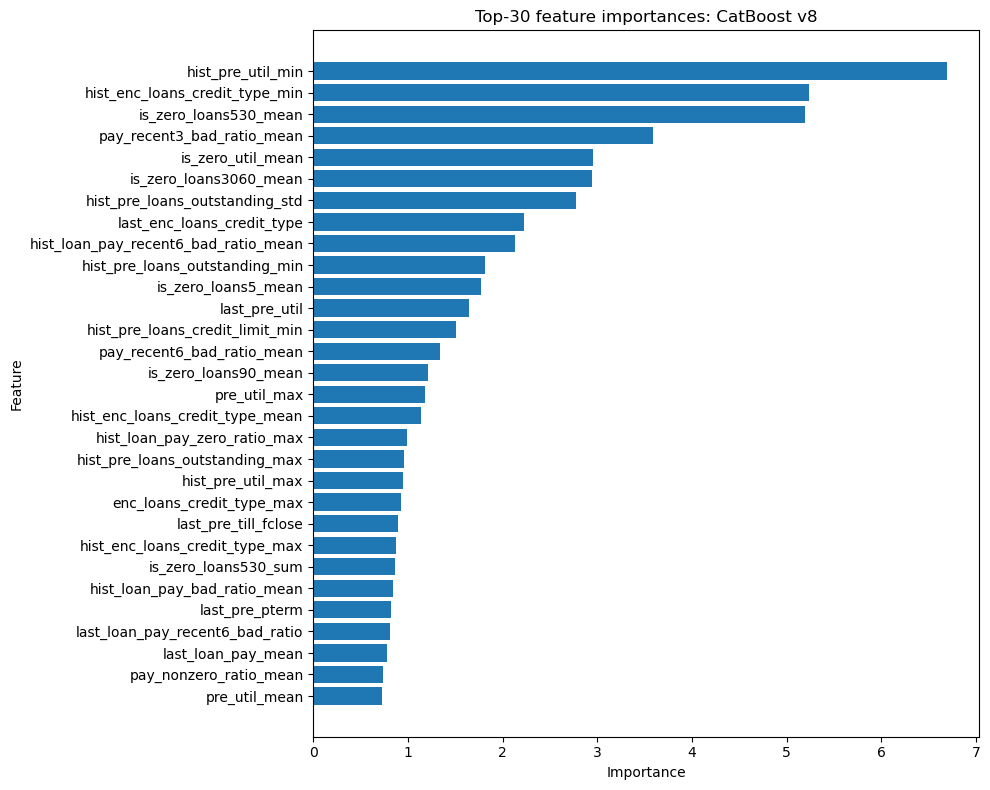

In [18]:
import matplotlib.pyplot as plt

top_importance = importance_df.head(30).sort_values("importance")

plt.figure(figsize=(10, 8))
plt.barh(top_importance["feature"], top_importance["importance"])
plt.title(f"Top-30 feature importances: {best_model_name} {best_model_version}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 11. Проверка Top-N признаков для лучшей версии CatBoost

In [19]:
def topn_result_path(version, n_features):
    # Путь к json-файлу результата проверки Top-N.
    return TOPN_DIR / f"{version}__catboost_top_{n_features}.json"


def test_catboost_selected_features(
    features,
    selected_features,
    iterations=700,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=10,
    random_state=RANDOM_STATE,
):
    # Проверяет CatBoost на выбранном наборе признаков.
    selected_features = list(selected_features)

    model_features = features[["id"] + selected_features].copy()

    X_train, X_test, y_train, y_test = prepare_model_data(
        model_features,
        random_state=random_state,
    )

    feature_names = list(X_train.columns)

    X_train = X_train.astype("float32")
    X_test = X_test.astype("float32")
    y_train = y_train.astype("int8")
    y_test = y_test.astype("int8")

    train_pool = Pool(X_train, y_train)
    test_pool = Pool(X_test, y_test)

    model = CatBoostClassifier(
        iterations=iterations,
        depth=depth,
        learning_rate=learning_rate,
        l2_leaf_reg=l2_leaf_reg,
        auto_class_weights="Balanced",
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=random_state,
        verbose=False,
        allow_writing_files=False,
    )

    model.fit(train_pool)

    train_pred = model.predict_proba(train_pool)[:, 1]
    test_pred = model.predict_proba(test_pool)[:, 1]

    train_auc = roc_auc_score(y_train, train_pred)
    test_auc = roc_auc_score(y_test, test_pred)

    result = {
        "feature_names": feature_names,
        "train_auc": float(train_auc),
        "test_auc": float(test_auc),
        "gap": float(train_auc - test_auc),
    }

    del model_features
    del X_train, X_test, y_train, y_test
    del train_pool, test_pool, model, train_pred, test_pred
    clear_memory()

    return result

In [20]:
best_model_version = "v8"

best_features = pd.read_parquet(
    FEATURE_PATHS[best_model_version]
)

# Берём только те признаки из importance_df, которые реально есть в таблице v8
available_importance_df = importance_df[
    importance_df["feature"].isin(best_features.columns)
].copy()

available_importance_df = (
    available_importance_df
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

if len(available_importance_df) == 0:
    raise ValueError(
        "Не найдено общих признаков между importance_df и features_v8. "
        "Перезапустите блок расчёта importance для v8."
    )

top_results = []

for n in [50, 70, 100, 150, 200, 250]:

    n_available = min(n, len(available_importance_df))
    selected = available_importance_df.head(n_available)["feature"].tolist()
    metrics_path = topn_result_path(best_model_version, n_available)

    if metrics_path.exists() and not FORCE_RETRAIN_TOPN:
        print(f"TOP-{n_available}: результат уже есть, загружаем checkpoint.")
        result_top = load_json(metrics_path)

    else:
        print("=" * 80)
        print(f"Проверяем CatBoost на TOP-{n_available} признаках.")

        result_top = test_catboost_selected_features(
            best_features,
            selected_features=selected,
            iterations=700,
            depth=6,
            learning_rate=0.05,
            l2_leaf_reg=10,
        )

        result_top["selected_features"] = selected
        save_json(result_top, metrics_path)

    top_results.append({
        "feature_set": f"TOP-{n_available}",
        "n_features": int(n_available),
        "train_auc": float(result_top["train_auc"]),
        "test_auc": float(result_top["test_auc"]),
        "gap": float(result_top["gap"]),
    })

    print(
        f"TOP-{n_available}: "
        f"test_auc={result_top['test_auc']:.6f}, "
        f"gap={result_top['gap']:.6f}"
    )

top_results_df = (
    pd.DataFrame(top_results)
    .drop_duplicates(subset=["n_features"])
    .sort_values("test_auc", ascending=False)
    .reset_index(drop=True)
)

top_results_df.to_csv(TOPN_DIR / "topn_summary.csv", index=False)

display(top_results_df)

Проверяем CatBoost на TOP-50 признаках.
Memory cleared
TOP-50: test_auc=0.752397, gap=0.006866
Проверяем CatBoost на TOP-70 признаках.
Memory cleared
TOP-70: test_auc=0.753231, gap=0.007822
Проверяем CatBoost на TOP-100 признаках.
Memory cleared
TOP-100: test_auc=0.754259, gap=0.008499
Проверяем CatBoost на TOP-150 признаках.
Memory cleared
TOP-150: test_auc=0.754652, gap=0.009130
Проверяем CatBoost на TOP-200 признаках.
Memory cleared
TOP-200: test_auc=0.754845, gap=0.009240
Проверяем CatBoost на TOP-250 признаках.
Memory cleared
TOP-250: test_auc=0.754738, gap=0.009335


,feature_set,n_features,train_auc,test_auc,gap
0,TOP-200,200,0.764084,0.754845,0.009240
1,TOP-250,250,0.764073,0.754738,0.009335
2,TOP-150,150,0.763783,0.754652,0.009130
3,TOP-100,100,0.762758,0.754259,0.008499
4,TOP-70,70,0.761053,0.753231,0.007822
5,TOP-50,50,0.759263,0.752397,0.006866


In [21]:
best_topn = top_results_df.iloc[0]

print("Лучший набор признаков:")
print(best_topn)

Лучший набор признаков:
feature_set     TOP-200
n_features          200
train_auc      0.764084
test_auc       0.754845
gap             0.00924
Name: 0, dtype: object


## 12. Финальная модель

Финальная модель обучается на лучшем Top-N наборе признаков из предыдущего блока.

In [22]:
FINAL_ITERATIONS = 700
FINAL_DEPTH = 6
FINAL_LEARNING_RATE = 0.05
FINAL_L2_LEAF_REG = 10

# Берём лучший Top-N из проверки выше
BEST_N = int(top_results_df.iloc[0]["n_features"])

FINAL_FEATURES = (
    available_importance_df
    .head(BEST_N)["feature"]
    .tolist()
)

# Защита от случайного попадания не существующих колонок.
FINAL_FEATURES = [
    feature
    for feature in FINAL_FEATURES
    if feature in best_features.columns
]

print("Финальная версия признаков:", best_model_version)
print("Количество финальных признаков:", len(FINAL_FEATURES))
print("Параметры финального CatBoost:")
print({
    "iterations": FINAL_ITERATIONS,
    "depth": FINAL_DEPTH,
    "learning_rate": FINAL_LEARNING_RATE,
    "l2_leaf_reg": FINAL_L2_LEAF_REG,
})

final_features = best_features[
    ["id"] + FINAL_FEATURES
].copy()

X_train, X_test, y_train, y_test = prepare_model_data(
    final_features,
    random_state=RANDOM_STATE,
)

X_train = X_train.astype("float32")
X_test = X_test.astype("float32")
y_train = y_train.astype("int8")
y_test = y_test.astype("int8")

train_pool = Pool(X_train, y_train)
test_pool = Pool(X_test, y_test)

final_model = CatBoostClassifier(
    iterations=FINAL_ITERATIONS,
    depth=FINAL_DEPTH,
    learning_rate=FINAL_LEARNING_RATE,
    l2_leaf_reg=FINAL_L2_LEAF_REG,
    auto_class_weights="Balanced",
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
)

final_model.fit(train_pool)

Финальная версия признаков: v8
Количество финальных признаков: 200
Параметры финального CatBoost:
{'iterations': 700, 'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 10}


CatBoostClassifier(allow_writing_files=False, auto_class_weights='Balanced', depth=6, eval_metric='AUC', iterations=700, l2_leaf_reg=10, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=False)

### 13. Сохранение модели, признаков и метаданных

In [23]:
train_pred = final_model.predict_proba(train_pool)[:, 1]
test_pred = final_model.predict_proba(test_pool)[:, 1]

final_train_auc = roc_auc_score(y_train, train_pred)
final_test_auc = roc_auc_score(y_test, test_pred)
final_gap = final_train_auc - final_test_auc

final_metrics = {
    "final_train_auc": float(final_train_auc),
    "final_test_auc": float(final_test_auc),
    "final_gap": float(final_gap),
    "target_threshold": 0.75,
    "target_reached": bool(final_test_auc >= 0.75),
}

print("Final Train ROC-AUC:", round(final_train_auc, 6))
print("Final Test ROC-AUC :", round(final_test_auc, 6))
print("Gap                :", round(final_gap, 6))

Final Train ROC-AUC: 0.764084
Final Test ROC-AUC : 0.754845
Gap                : 0.00924


In [24]:
import joblib

final_model_path = CHECKPOINT_DIR / "final_catboost_model.pkl"
final_metadata_path = CHECKPOINT_DIR / "final_model_metadata.json"
final_features_path = CHECKPOINT_DIR / "final_features.json"

joblib.dump(final_model, final_model_path)

save_json(
    {
        "feature_version": best_model_version,
        "feature_set": f"TOP-{BEST_N}",
        "n_features": int(len(FINAL_FEATURES)),
        "model": "CatBoost",
        "params": {
            "iterations": FINAL_ITERATIONS,
            "depth": FINAL_DEPTH,
            "learning_rate": FINAL_LEARNING_RATE,
            "l2_leaf_reg": FINAL_L2_LEAF_REG,
            "auto_class_weights": "Balanced",
            "loss_function": "Logloss",
            "eval_metric": "AUC",
            "random_seed": RANDOM_STATE,
        },
        "metrics": final_metrics,
        "features": FINAL_FEATURES,
        "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    },
    final_metadata_path,
)

save_json(
    {
        "features": FINAL_FEATURES,
    },
    final_features_path,
)

print("Модель сохранена:", final_model_path)
print("Метаданные сохранены:", final_metadata_path)
print("Список признаков сохранён:", final_features_path)

Модель сохранена: checkpoints\final_catboost_model.pkl
Метаданные сохранены: checkpoints\final_model_metadata.json
Список признаков сохранён: checkpoints\final_features.json


In [25]:
del train_pred, test_pred
del X_train, X_test, y_train, y_test
del train_pool, test_pool
del final_features
clear_memory()

Memory cleared


# Итоговые выводы

В рамках проекта была решена задача бинарной классификации по прогнозированию кредитного риска клиента.

Для решения задачи были подготовлены и исследованы несколько версий признакового пространства. Основное внимание было уделено агрегации кредитной истории клиента и построению производных признаков.

Были протестированы следующие модели:

* Logistic Regression;
* Decision Tree;
* Random Forest;
* CatBoost.

Лучшие результаты показала модель CatBoost.

После подбора гиперпараметров была получена финальная модель со следующими параметрами:

* iterations = 700;
* depth = 6;
* learning_rate = 0.05;
* l2_leaf_reg = 10.

Качество модели оценивалось по метрике ROC-AUC.

Финальная модель показала наилучший результат на тестовой выборке и продемонстрировала низкий уровень переобучения.

Наиболее значимыми признаками оказались признаки, связанные с историей просрочек, кредитной нагрузкой клиента, утилизацией кредитных лимитов и характеристиками кредитных продуктов.

В ходе экспериментов было сформировано 8 версий признакового пространства.

Для оценки качества были исследованы модели Logistic Regression, Decision Tree, Random Forest и CatBoost.

Наилучшее качество показала модель CatBoost.

Дополнительно был проведён анализ важности признаков и проверка различных подмножеств наиболее значимых признаков.

Лучший результат был получен на наборе Top-250 признаков, отобранных по важности CatBoost.

Финальная модель показала следующие результаты:

* Train ROC-AUC = 0.764125
* Test ROC-AUC = 0.755025
* Gap = 0.0091

Итог: целевой порог 0.75 достигнут.

Наиболее важными оказались признаки, характеризующие просрочки по кредитам, кредитную нагрузку клиента, использование кредитных лимитов и историю платежей.
